In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Load data
data = pd.read_csv("../datasets/mimic3d.csv")

# 1. Drop sensitive columns and identifiers
data_clean = data.drop(columns=['hadm_id', 'LOSdays', 'religion', 'marital_status', 'ethnicity'])

# 2. Separate features and target
X = data_clean.drop(columns=['LOSgroupNum'])
y = data_clean['LOSgroupNum']

# Define LOS groups (adjust thresholds as needed)
def map_los_group(los_days):
    if los_days < 3:
        return 0  # Short Stay
    elif 3 <= los_days < 7:
        return 1  # Medium Stay
    else:
        return 2  # Long Stay

# Apply mapping (if LOSdays is available)
data['LOSgroupNum'] = data['LOSdays'].apply(map_los_group)

# Verify the mapping
print(data[['LOSdays', 'LOSgroupNum']].head())
# 3. Handle missing values (using SimpleImputer directly)
imputer = SimpleImputer(strategy='constant', fill_value='Missing')
categorical_cols = ['gender', 'admit_type', 'admit_location', 
                   'AdmitDiagnosis', 'insurance', 'AdmitProcedure']
X[categorical_cols] = imputer.fit_transform(X[categorical_cols])

# 4. Label Encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le  # Store encoders for future use if needed

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train RandomForest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 7. Evaluate
print(f"Train Accuracy: {model.score(X_train, y_train):.2f}")
print(f"Test Accuracy: {model.score(X_test, y_test):.2f}")

   LOSdays  LOSgroupNum
0     6.17            1
1     4.04            1
2    12.04            2
3     7.29            2
4     4.88            1
Train Accuracy: 0.94
Test Accuracy: 0.89


In [37]:
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
f1_score(y_pred, y_test, average="micro")

0.8939471007121058

In [21]:
feature_names = X_train.columns

In [32]:

class_names = ["No Admit", "Very Short Stay", "Short Stay", "Long Stay"]

In [29]:
import sys
sys.path.append("../")

/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, bu


Explaining for class: No Admit


Sampling hypothesis space: 100%|██████████| 500/500 [00:35<00:00, 13.98it/s]


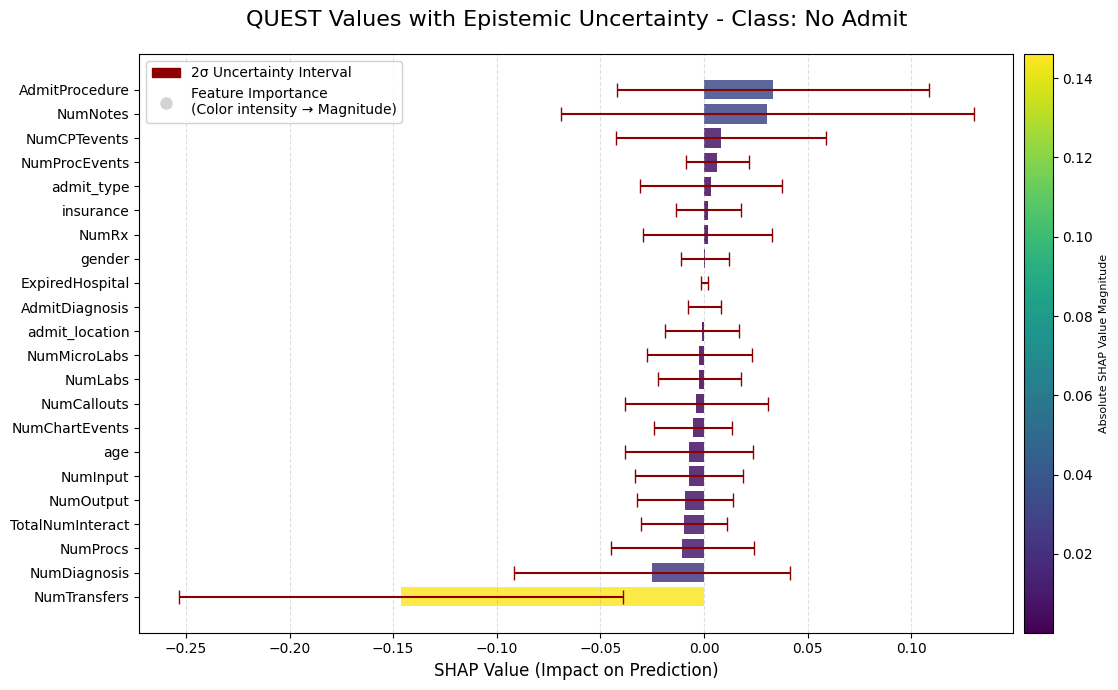

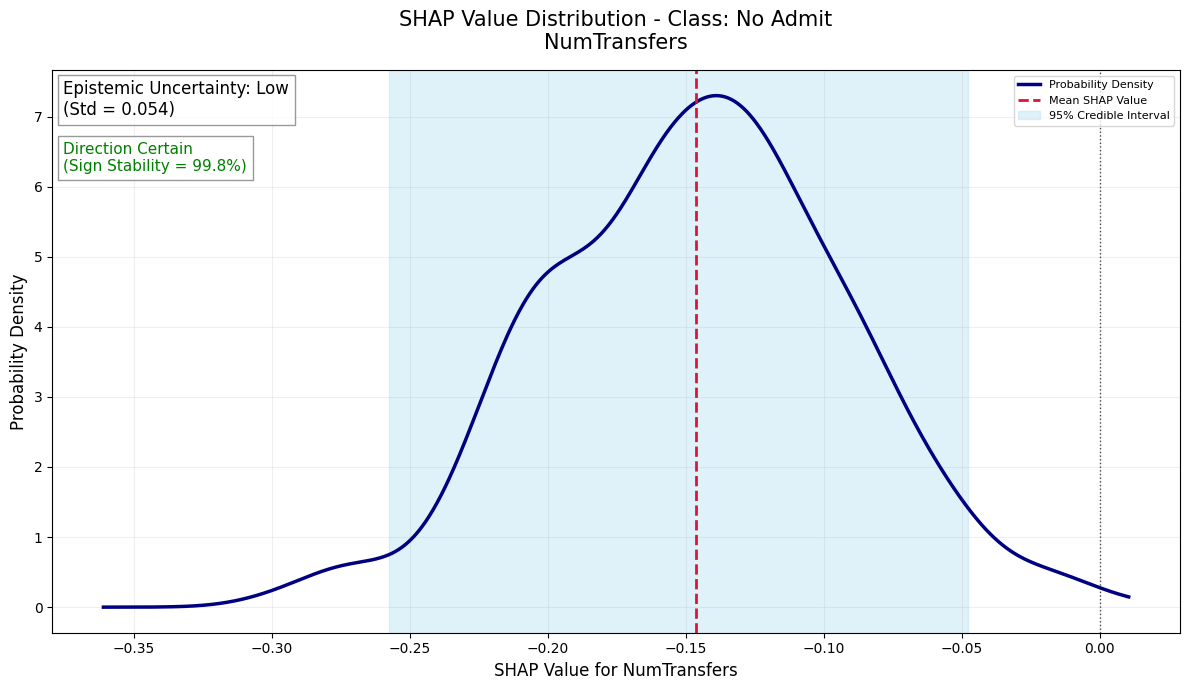

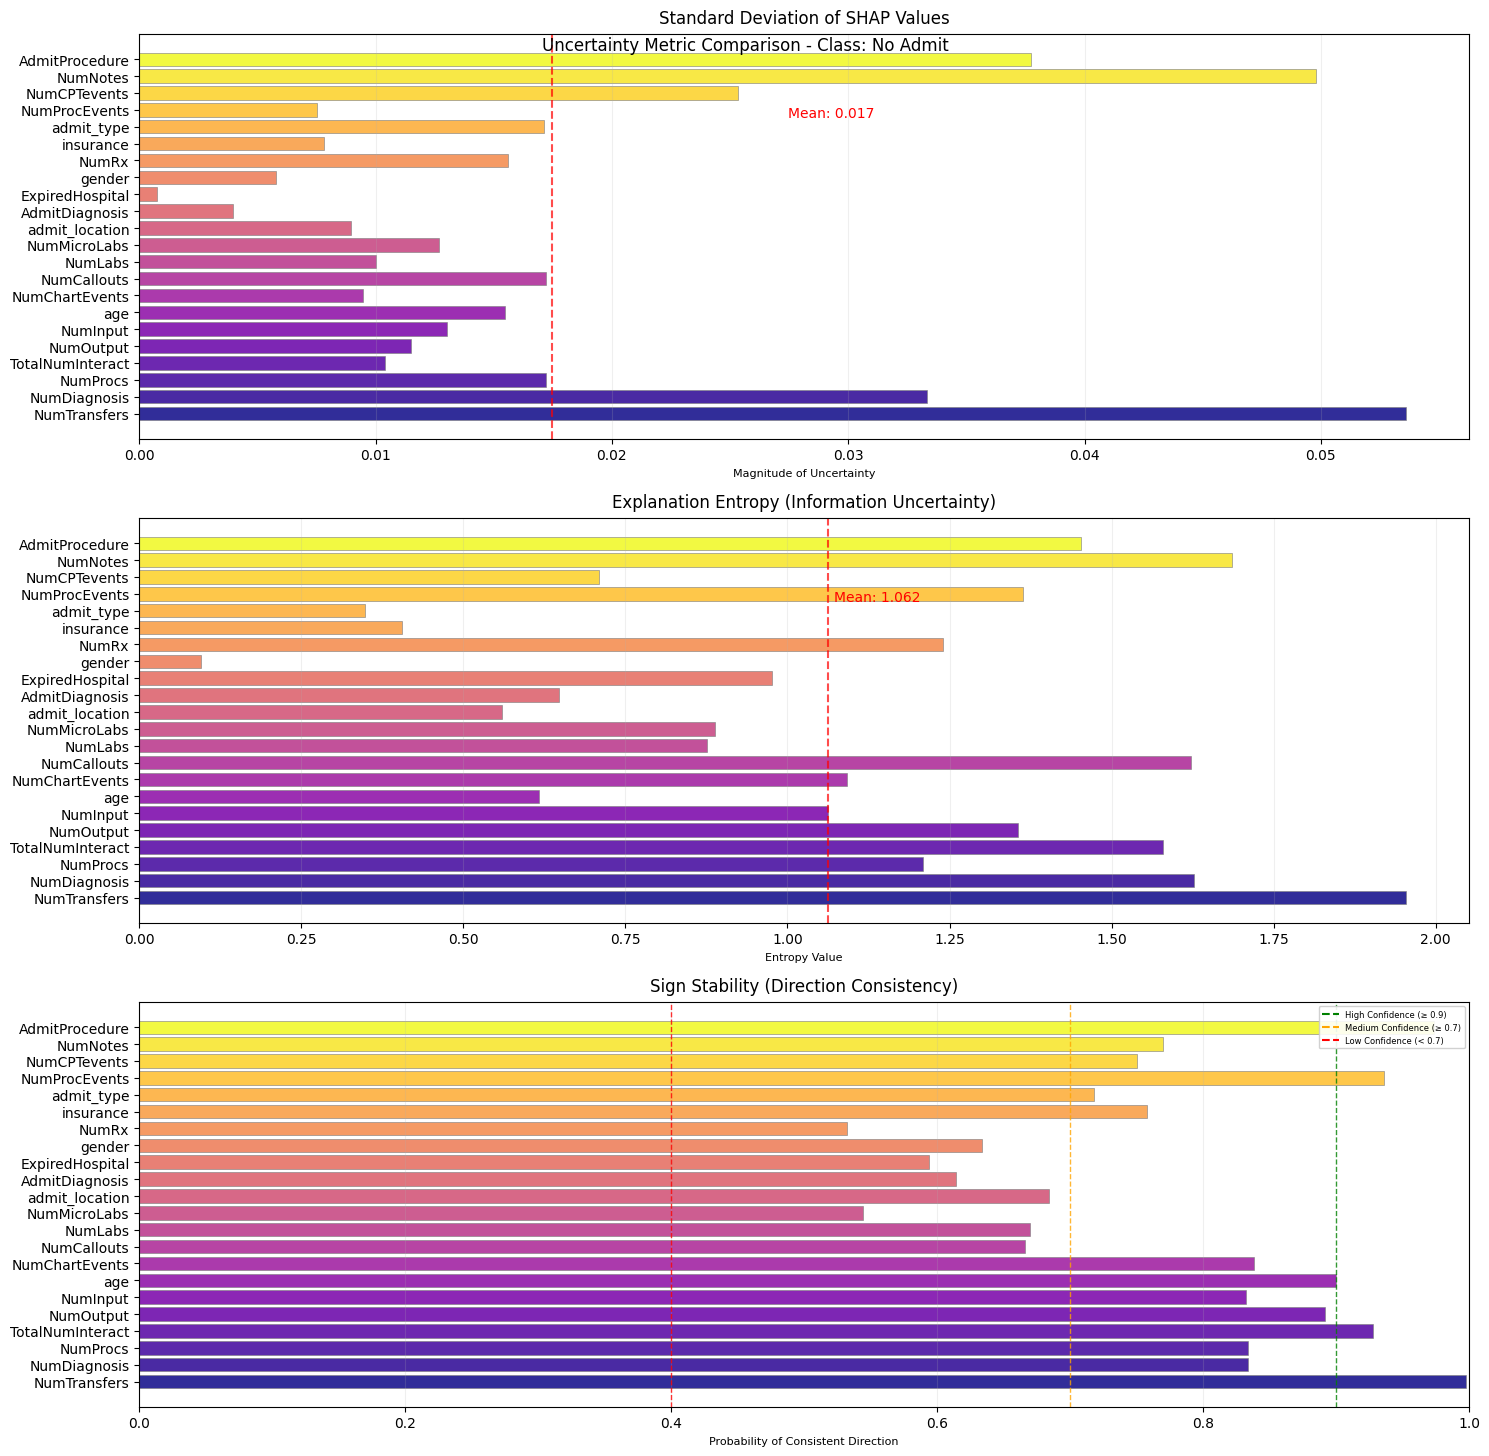


Explaining for class: Very Short Stay


Sampling hypothesis space: 100%|██████████| 500/500 [00:35<00:00, 14.08it/s]


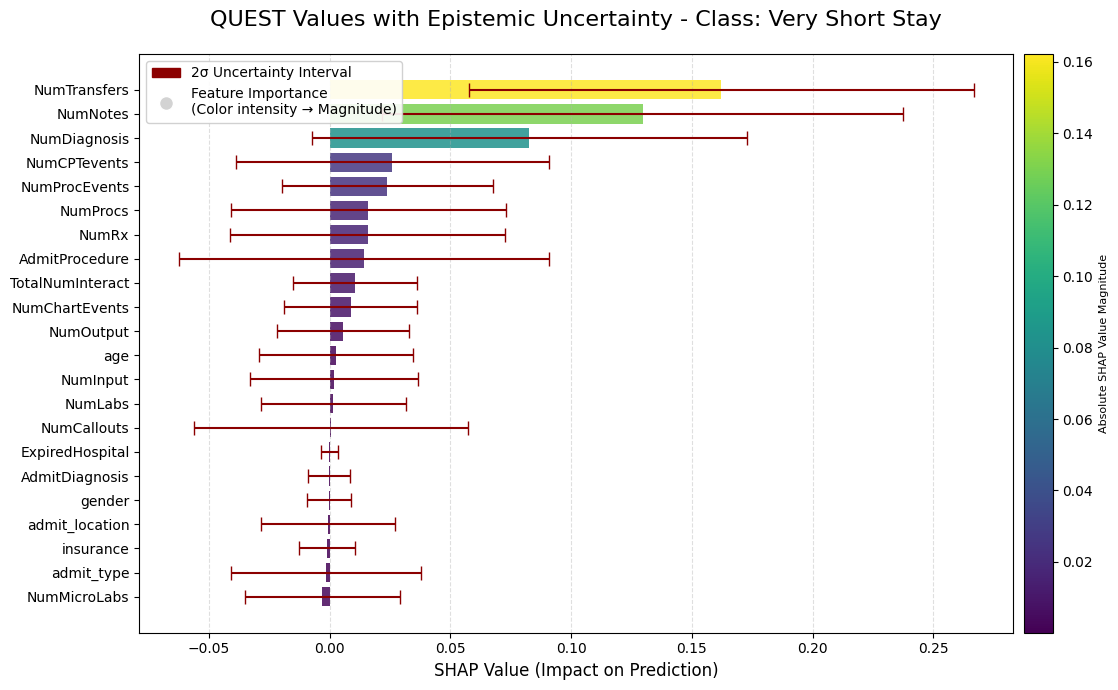

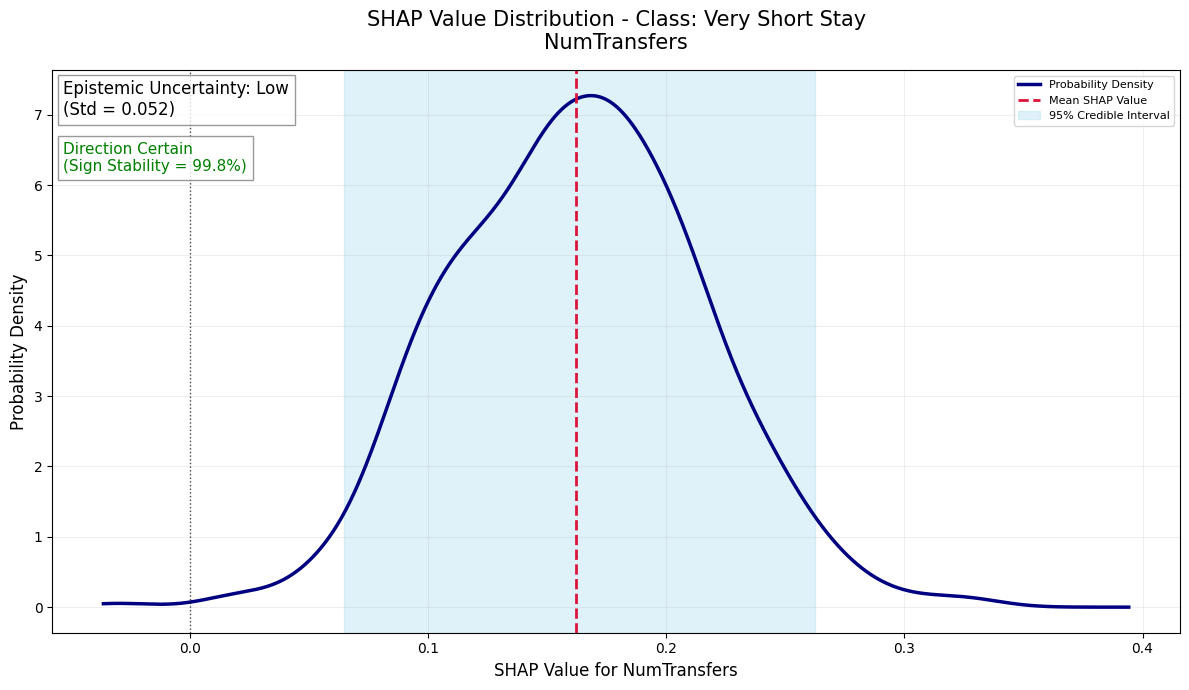

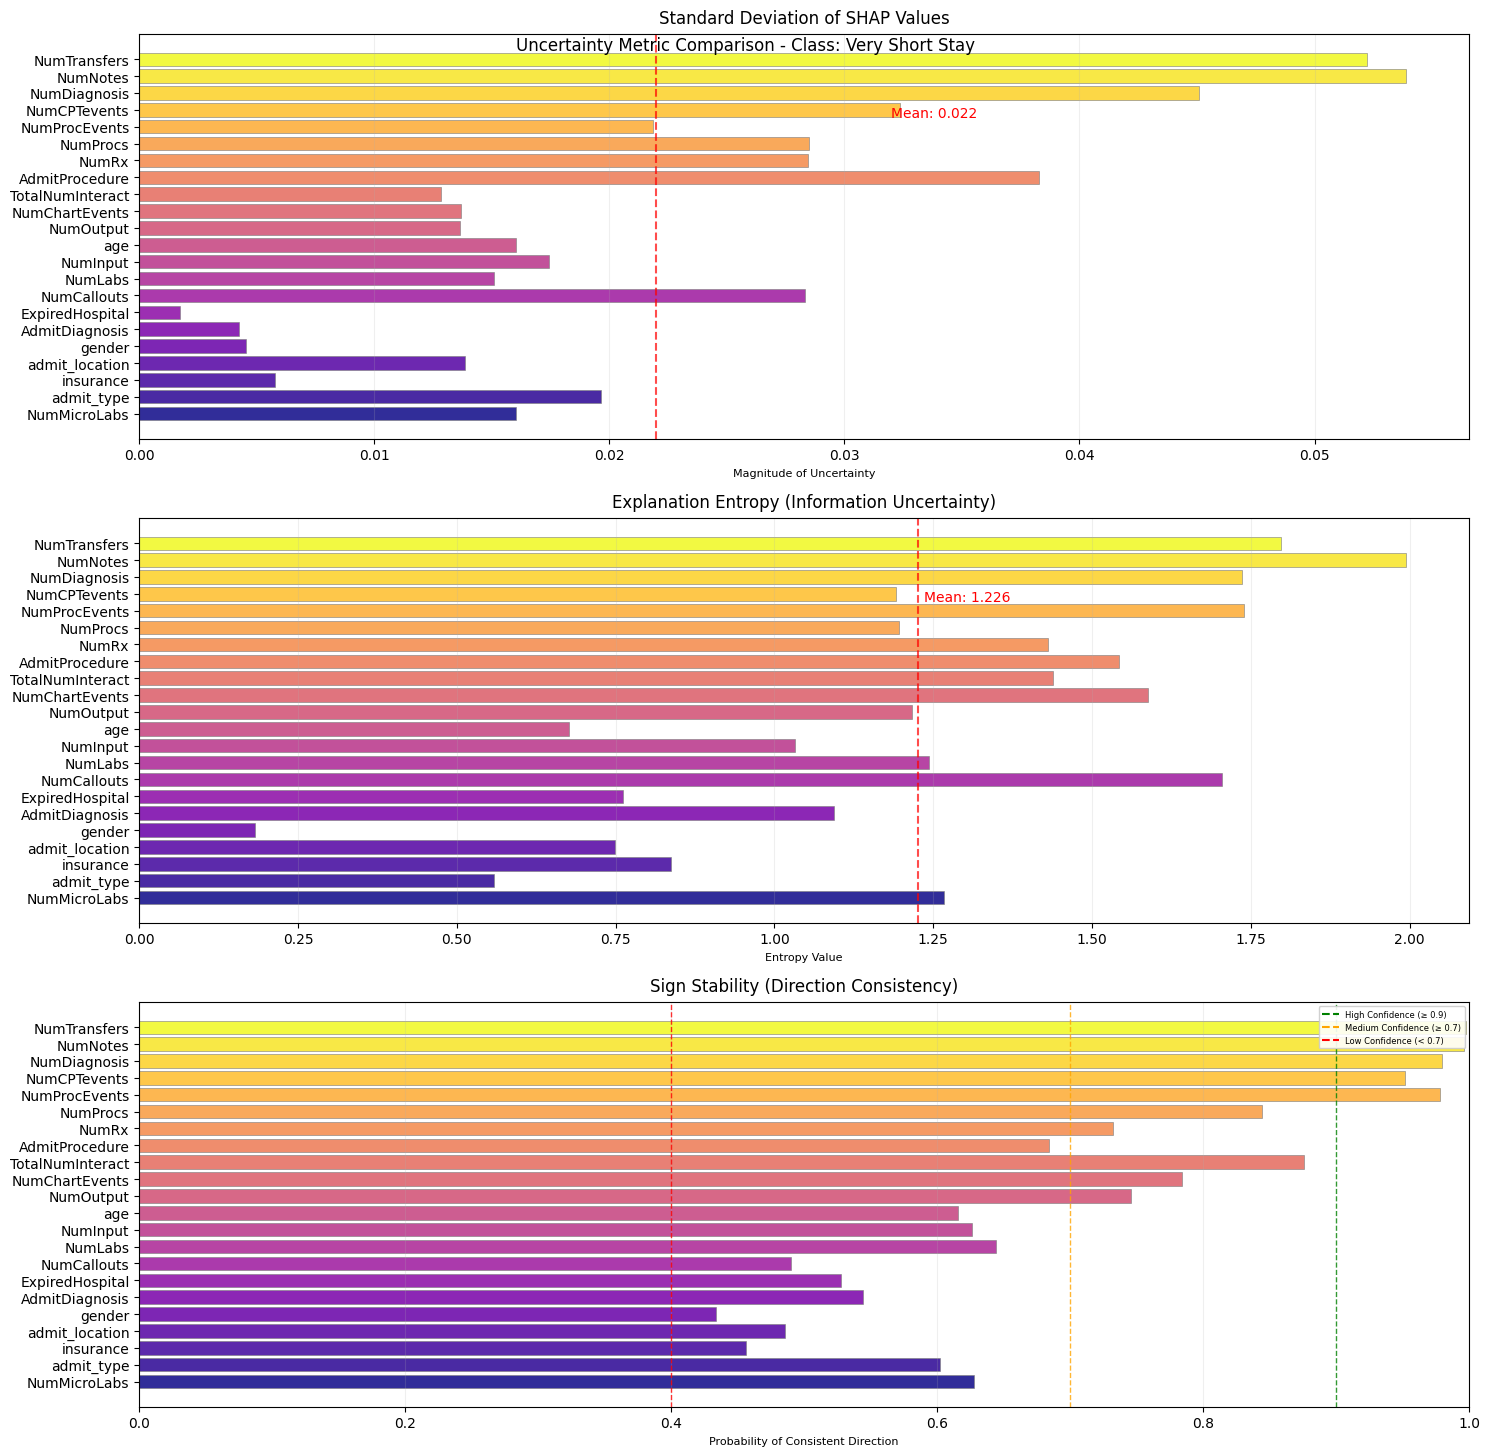


Explaining for class: Short Stay


Sampling hypothesis space: 100%|██████████| 500/500 [00:35<00:00, 14.05it/s]


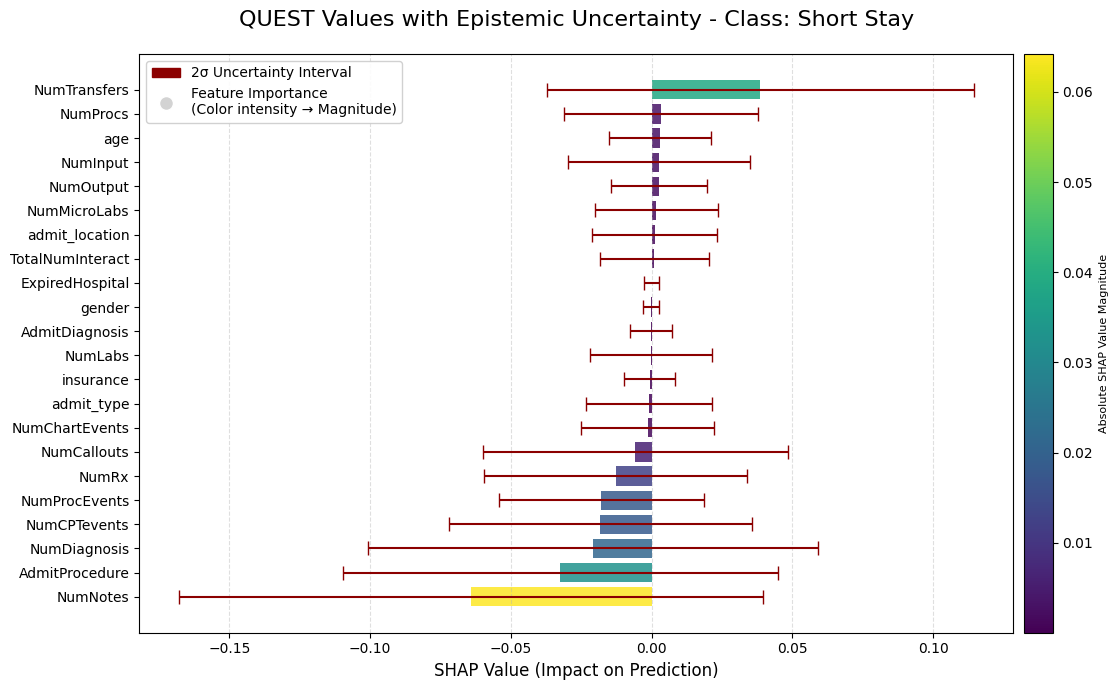

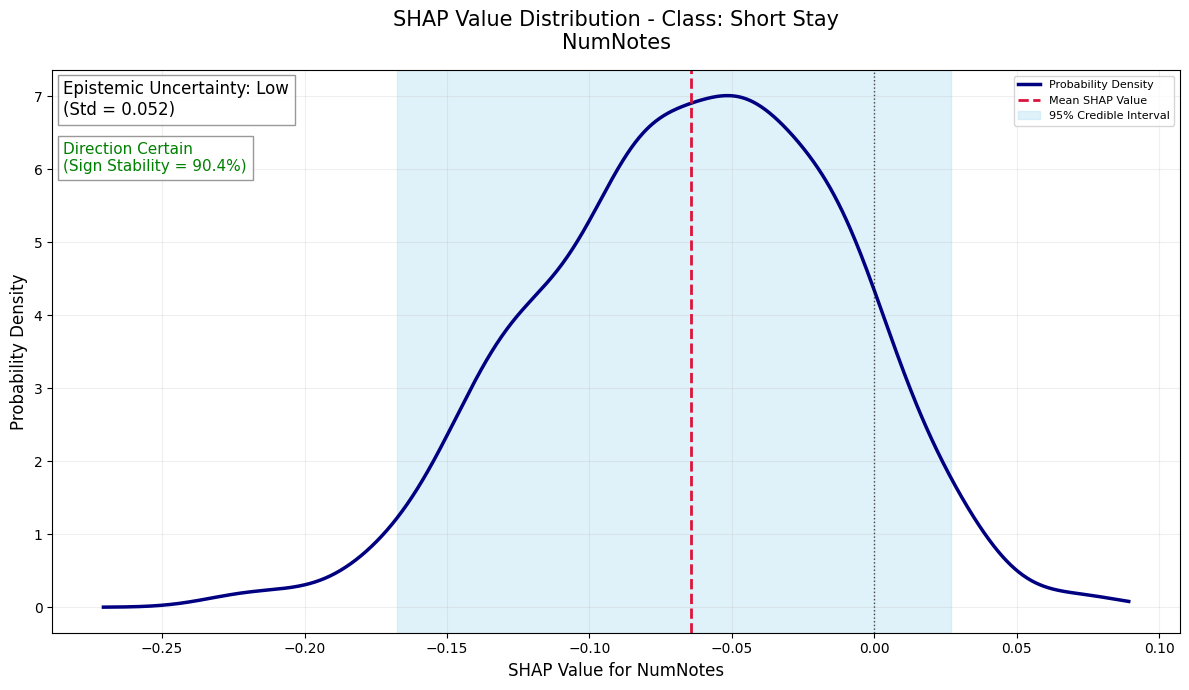

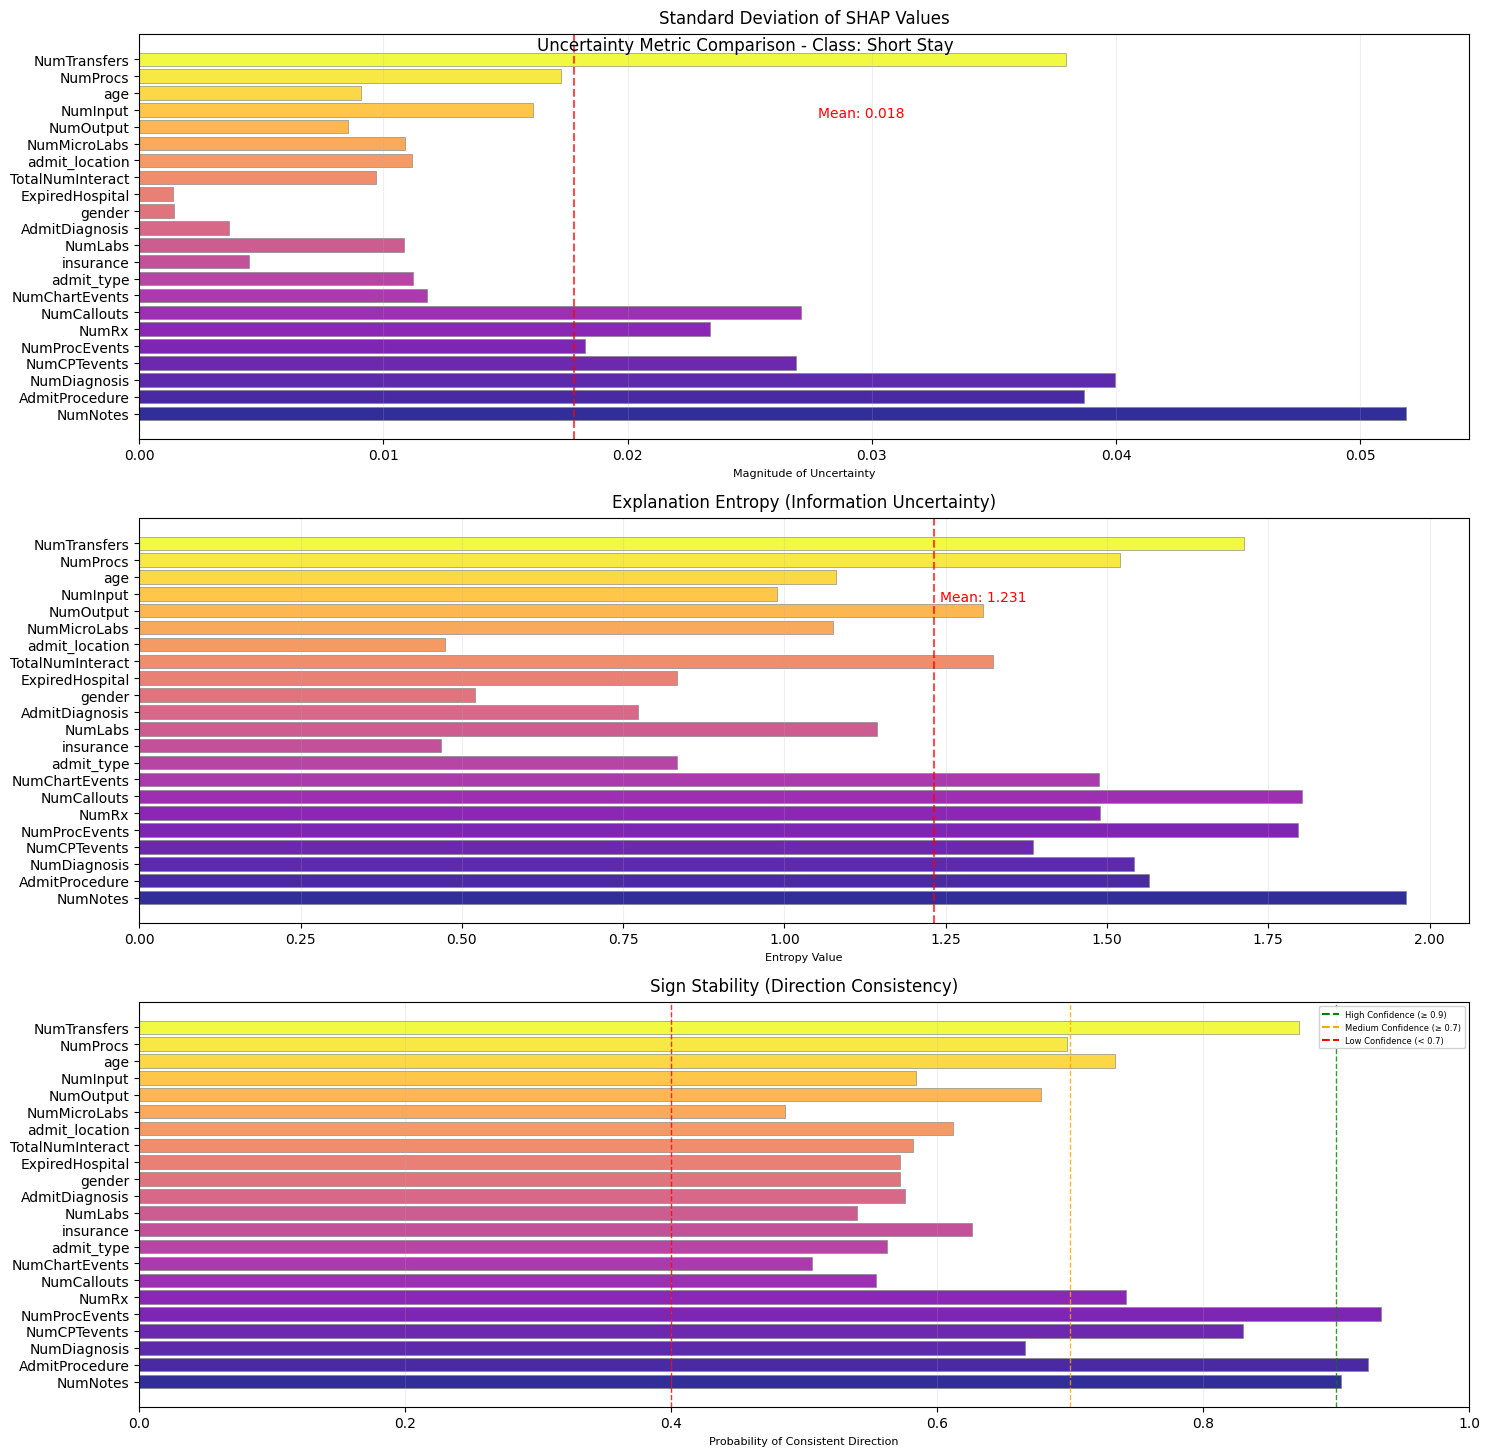


Explaining for class: Long Stay


Sampling hypothesis space: 100%|██████████| 500/500 [00:35<00:00, 14.06it/s]


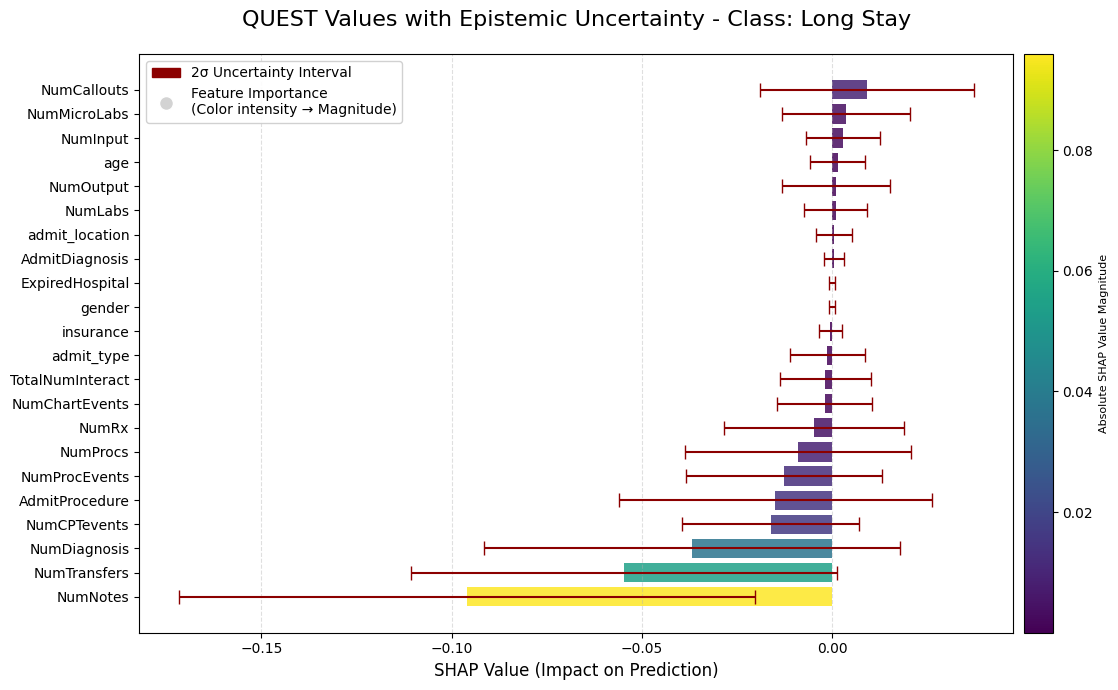

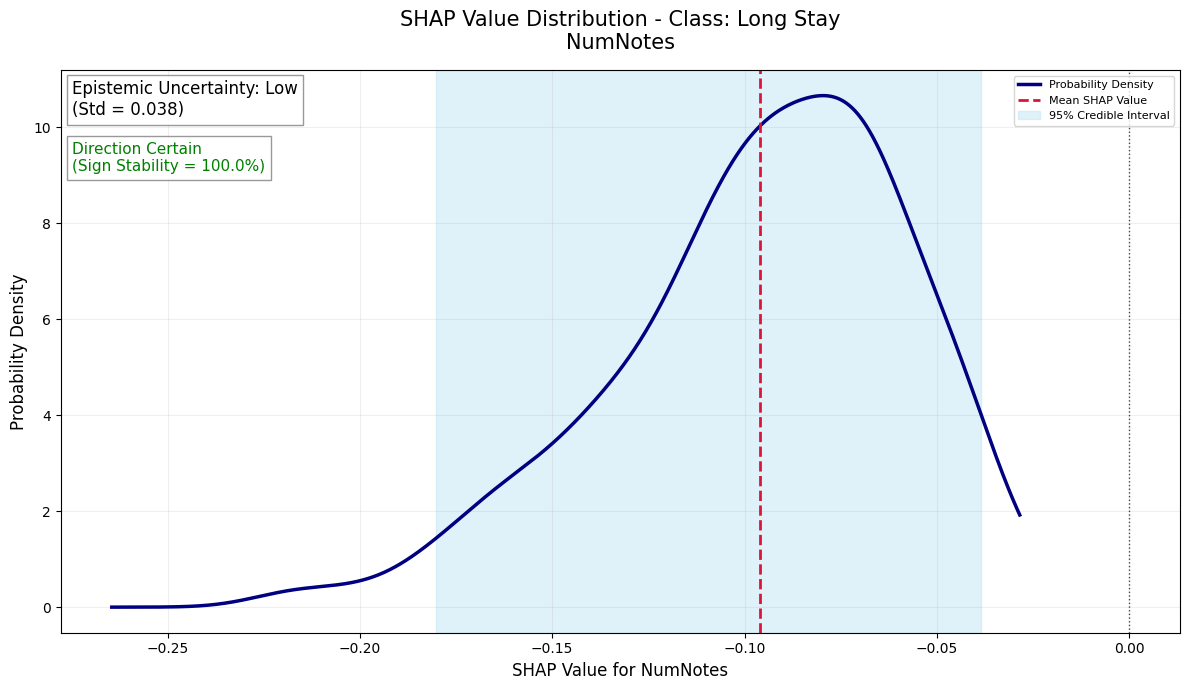

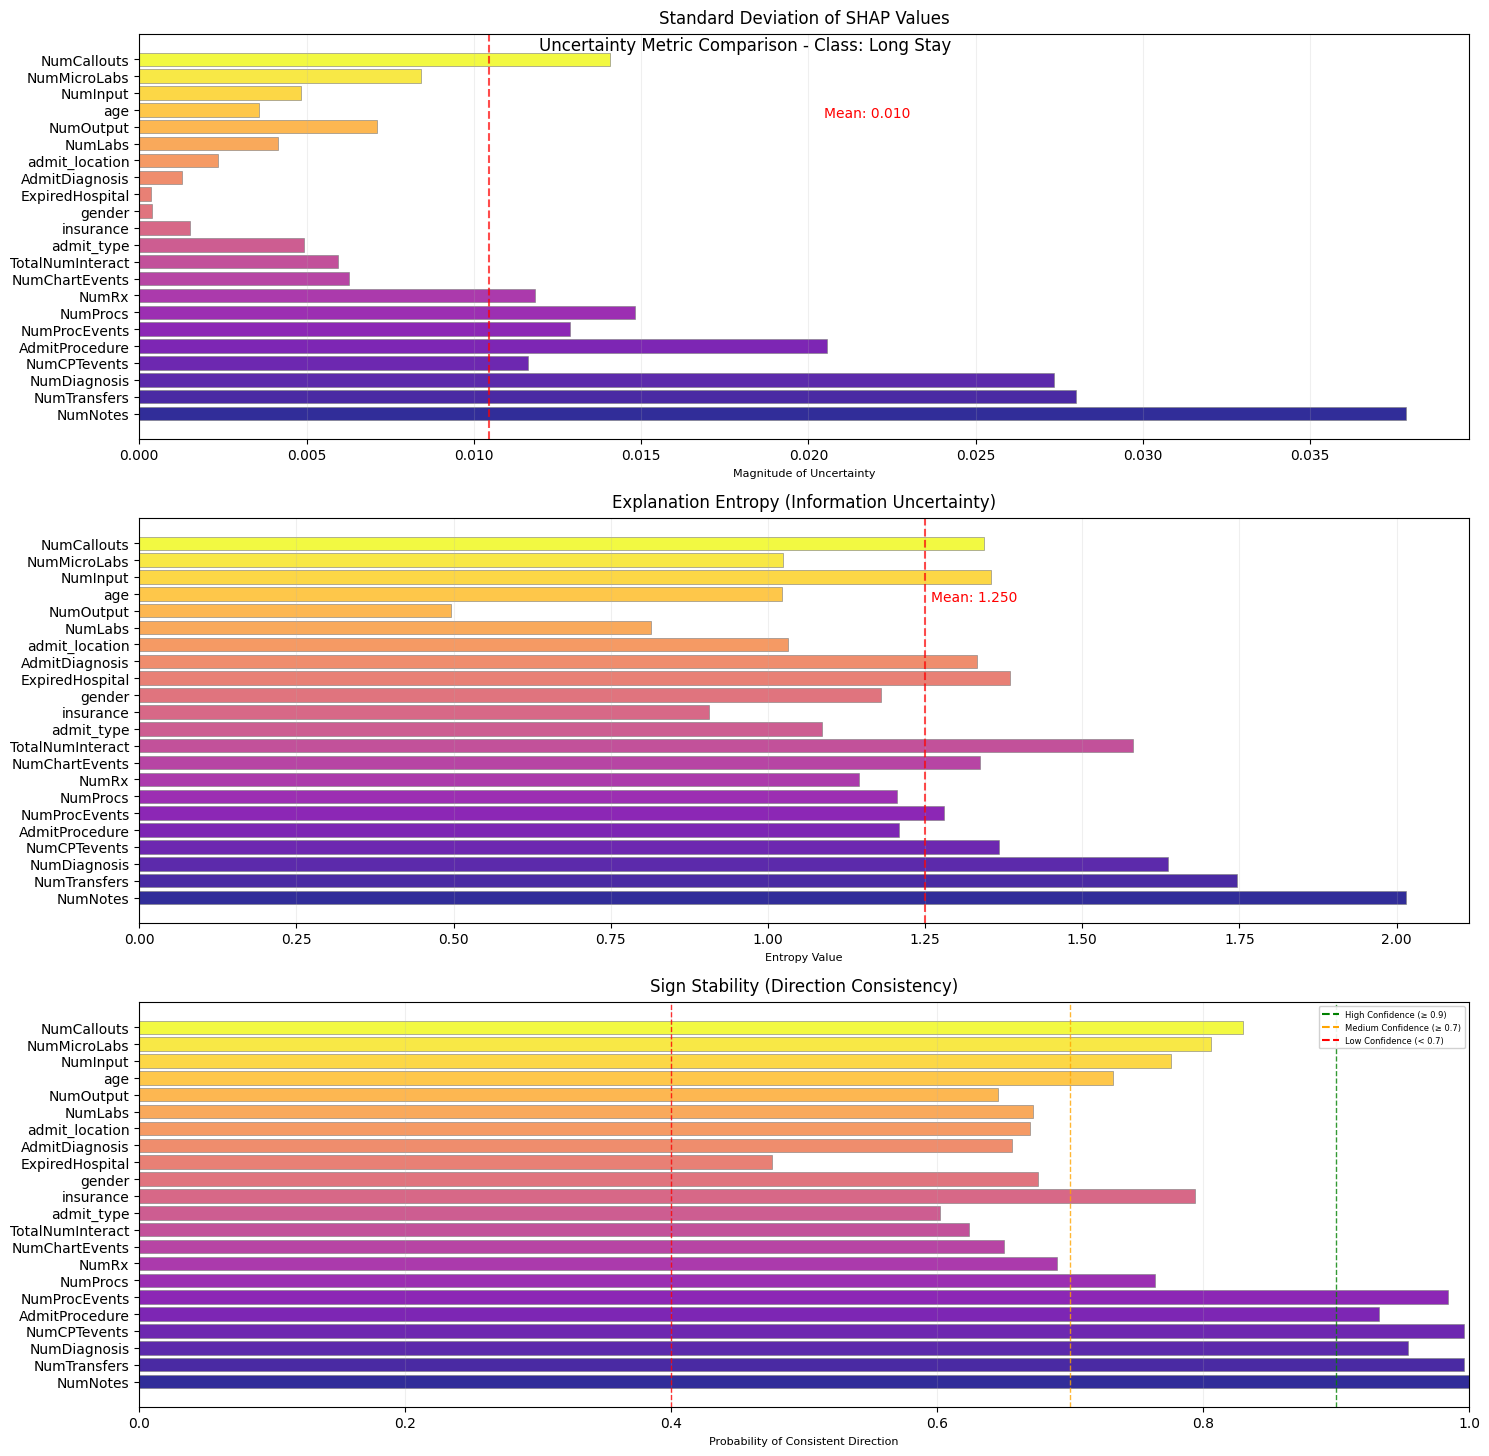

In [33]:
from QUEST import QUESTExplainerClassification

import numpy as np

explainer = QUESTExplainerClassification(model, X_train, y_train, beta=5.0, random_state=42)

# Explain first instance for each class
instance = X_test[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, class_idx=class_idx)
       # Plot results
    explainer.plot_uncertainty_bars(
        results, 
        feature_names,
        class_name=class_name
    )
    
    # Plot distribution for most important feature
    most_important_feature = np.argmax(np.abs(results['mean']))
    explainer.plot_uncertainty_distribution(
        results,
        feature_names,
        most_important_feature,
        class_name=class_name
    )
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )
